# Fitting a Separating Line: Largest-Gap LP vs SVM

This notebook compares two ways to fit a linear separator in 2D:

- **Largest-gap linear program (LP)**
- **Linear SVM**

Both produce a line of the form `w1*x1 + w2*x2 + b = 0`, but they optimize different objectives, so they can produce different boundaries.

## Optimization models

Largest-gap LP used here:

Maximize `t`

subject to: `y_i * (w^T x_i + b) >= t` for all `i`, and `||w||_1 <= 1`.

Linear SVM (soft-margin): minimizes `0.5 * ||w||_2^2 + C * sum(xi_i)` with hinge-loss slack variables.

The norm and loss are different (`L1` normalization in LP vs `L2` regularization + hinge loss in SVM), so the fitted lines are not generally the same.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog
from sklearn.svm import SVC

%config InlineBackend.figure_format = 'retina'

In [2]:
# A small, linearly separable dataset chosen so LP and SVM give noticeably different lines
X_pos = np.array([
    [2.5, 2.2], [3.0, 2.8], [2.2, 3.0], [3.4, 2.4], [2.8, 3.3], [4.8, 1.7]
])
X_neg = np.array([
    [0.3, 0.6], [0.8, 1.2], [1.0, 0.2], [1.3, 1.0], [1.5, 0.4], [2.2, -0.2]
])

X = np.vstack([X_pos, X_neg])
y = np.hstack([np.ones(len(X_pos)), -np.ones(len(X_neg))])

X.shape, y.shape

((12, 2), (12,))

In [3]:
# Largest-gap LP:
# max t s.t. y_i*(w^T x_i + b) >= t, ||w||_1 <= 1
# Use split variables: w = w+ - w-, b = b+ - b-, all >= 0

n = len(X)
# Variables: [w+1, w+2, w-1, w-2, b+, b-, t]
c = np.array([0, 0, 0, 0, 0, 0, -1.0])  # minimize -t

A_ub = []
b_ub = []

for i in range(n):
    x1, x2 = X[i]
    yi = y[i]
    # -yi*(x1*(w+1-w-1) + x2*(w+2-w-2) + (b+-b-)) + t <= 0
    A_ub.append([
        -yi * x1,
        -yi * x2,
         yi * x1,
         yi * x2,
        -yi,
         yi,
         1.0
    ])
    b_ub.append(0.0)

# ||w||_1 <= 1
A_ub.append([1, 1, 1, 1, 0, 0, 0])
b_ub.append(1.0)

A_ub = np.array(A_ub, dtype=float)
b_ub = np.array(b_ub, dtype=float)
bounds = [(0, None)] * 7

lp_res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')
if not lp_res.success:
    raise RuntimeError(lp_res.message)

w_lp = np.array([lp_res.x[0] - lp_res.x[2], lp_res.x[1] - lp_res.x[3]])
b_lp = lp_res.x[4] - lp_res.x[5]
t_lp = lp_res.x[6]

print('LP w =', w_lp)
print('LP b =', b_lp)
print('LP t =', t_lp)

LP w = [0.57142857 0.42857143]
LP b = -1.7714285714285707
LP t = 0.6000000000000005


In [4]:
# Linear SVM
svm = SVC(kernel='linear', C=1.0)
svm.fit(X, y)

w_svm = svm.coef_.ravel()
b_svm = svm.intercept_[0]

print('SVM w =', w_svm)
print('SVM b =', b_svm)
print('support vectors:', svm.support_vectors_.shape[0])

SVM w = [0.83333317 0.83333317]
SVM b = -2.9166661297897165
support vectors: 2


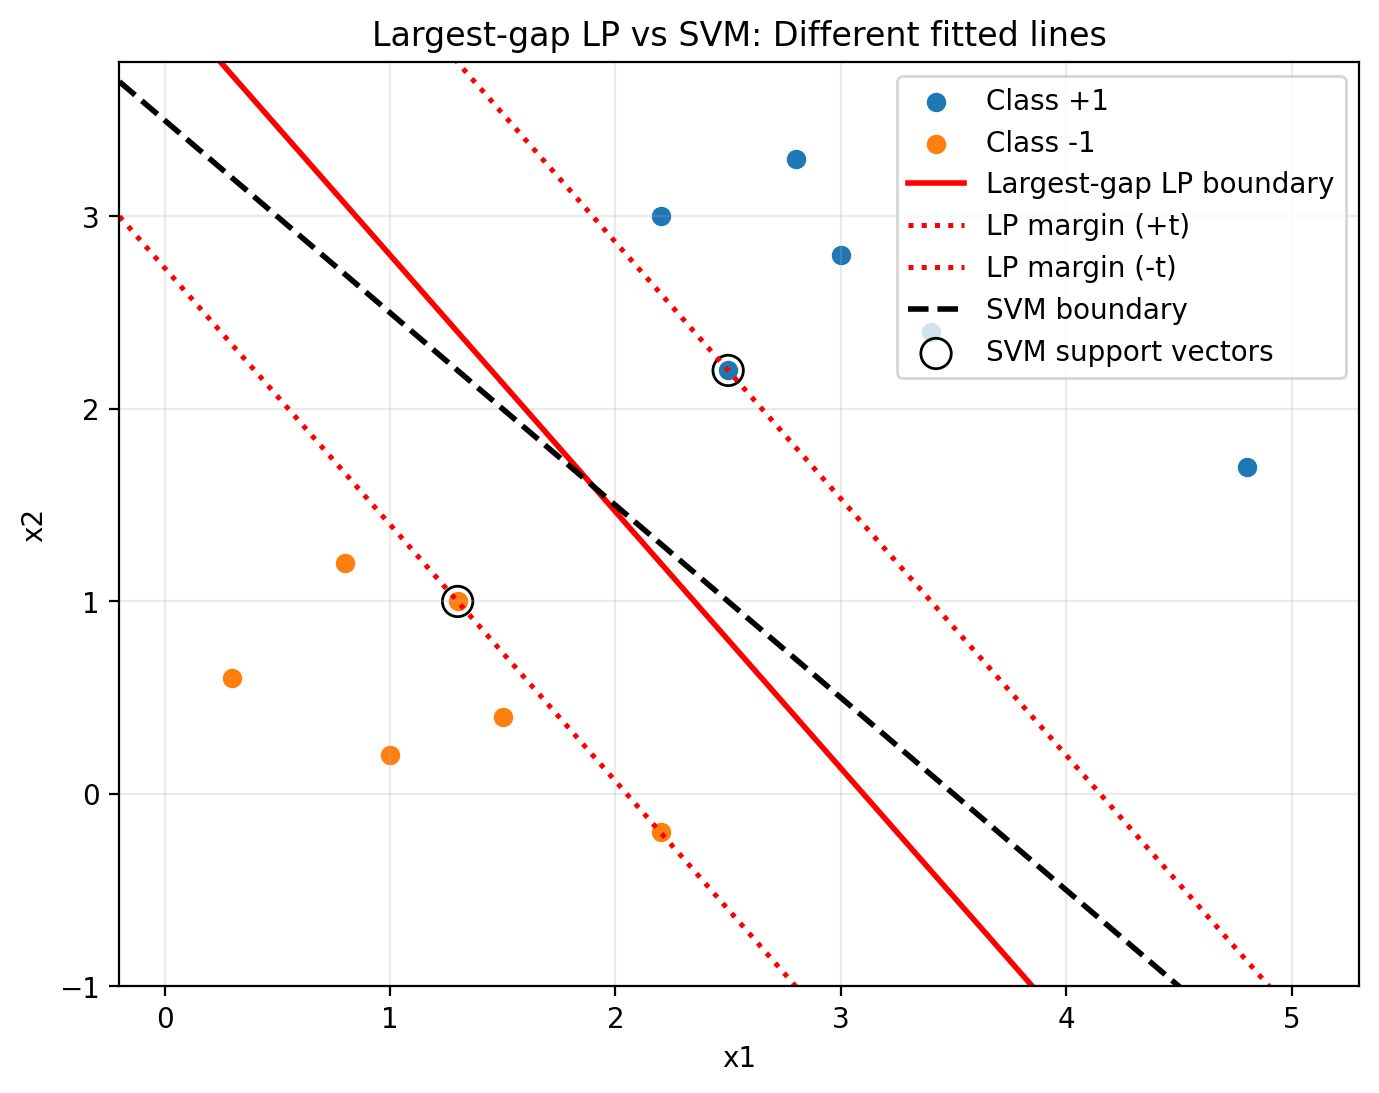

In [5]:
def y_on_line(x_vals, w, b):
    # w1*x + w2*y + b = 0 -> y = -(w1*x + b)/w2
    if abs(w[1]) < 1e-12:
        return None
    return -(w[0] * x_vals + b) / w[1]

x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.8, X[:, 1].max() + 0.5
xx = np.linspace(x_min, x_max, 300)

plt.figure(figsize=(8, 6))
plt.scatter(X_pos[:, 0], X_pos[:, 1], color='tab:blue', label='Class +1')
plt.scatter(X_neg[:, 0], X_neg[:, 1], color='tab:orange', label='Class -1')

y_lp = y_on_line(xx, w_lp, b_lp)
if y_lp is not None:
    plt.plot(xx, y_lp, 'r-', lw=2, label='Largest-gap LP boundary')

    # LP margins: w_lp^T x + b_lp = +/- t_lp
    y_lp_upper = y_on_line(xx, w_lp, b_lp - t_lp)
    y_lp_lower = y_on_line(xx, w_lp, b_lp + t_lp)
    plt.plot(xx, y_lp_upper, 'r:', lw=1.8, label='LP margin (+t)')
    plt.plot(xx, y_lp_lower, 'r:', lw=1.8, label='LP margin (-t)')
else:
    # Vertical LP boundary and margins when w_lp[1] == 0
    x_lp = -b_lp / w_lp[0]
    x_lp_upper = -(b_lp - t_lp) / w_lp[0]
    x_lp_lower = -(b_lp + t_lp) / w_lp[0]
    plt.axvline(x_lp, color='r', lw=2, label='Largest-gap LP boundary')
    plt.axvline(x_lp_upper, color='r', ls=':', lw=1.8, label='LP margin (+t)')
    plt.axvline(x_lp_lower, color='r', ls=':', lw=1.8, label='LP margin (-t)')

y_svm = y_on_line(xx, w_svm, b_svm)
if y_svm is not None:
    plt.plot(xx, y_svm, 'k--', lw=2, label='SVM boundary')

sv = svm.support_vectors_
plt.scatter(sv[:, 0], sv[:, 1], s=120, facecolors='none', edgecolors='k', label='SVM support vectors')

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Largest-gap LP vs SVM: Different fitted lines')
plt.grid(alpha=0.25)
plt.legend()
plt.show()


In [6]:
# Quantify line-direction difference
u = w_lp / np.linalg.norm(w_lp)
v = w_svm / np.linalg.norm(w_svm)
angle = np.degrees(np.arccos(np.clip(abs(np.dot(u, v)), -1.0, 1.0)))
print(f'Angle between normal vectors (acute): {angle:.2f} degrees')

Angle between normal vectors (acute): 8.13 degrees


## Why they differ

- The LP model maximizes margin-like score using an `L1` scale constraint on `w`.
- SVM uses `L2` regularization and hinge-loss slack (through `C`).
- Different norms and penalties select different trade-offs, so the resulting separator lines are typically different.